<a href="https://colab.research.google.com/github/munizgui/CP4_SERS/blob/main/Desafio_Final_Energia_ONS_API_Colab_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [2]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [3]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [4]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [5]:
dados = pd.DataFrame(registros)
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [6]:
dados.shape

(336, 11)

In [7]:
# Desenvolva aqui o DESAFIO 1

# 4. Listar os nomes dos atributos
print("Nomes dos atributos:")
print(dados.columns.tolist())

# 5. Utilizar info()
print("\nInformações do DataFrame:")
dados.info()

# 6. Utilizar describe()
print("\nEstatísticas descritivas:")
display(dados.describe(include="all"))

Nomes dos atributos:
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336,336,336,336,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
unique,1,7,7,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-07T19:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,336,48,48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,NaN,NaN,NaN,NaN,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,NaN,NaN,NaN,NaN,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,NaN,NaN,NaN,NaN,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,NaN,NaN,NaN,NaN,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,NaN,NaN,NaN,NaN,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0


7. Identificação dos atributos

Data/hora: din_referenciautc

Área de carga: cod_areacarga

Valor de carga: val_cargaglobal

O atributo din_referenciautc representa a data e hora da medição, cod_areacarga identifica a área de carga analisada e val_cargaglobal representa o valor da carga elétrica em MWmed.

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [8]:
# Desenvolva aqui o DESAFIO 2

# 1. Renomeie os principais atributos com nomes mais simples
mapeamento_colunas = {
    'din_referenciautc': 'data_hora',
    'cod_areacarga': 'area_carga',
    'val_cargaglobal': 'carga_mw'
}

# 2. Crie um novo DataFrame contendo apenas os atributos necessários
colunas_relevantes = list(mapeamento_colunas.keys())
dados_limpos = dados[colunas_relevantes].rename(columns=mapeamento_colunas)

# 3 e 4. Verifique valores ausentes
valores_ausentes = dados_limpos.isnull().sum()
print("--- Valores Ausentes Por Atributo ---")
print(valores_ausentes)
print()

# 5. Verifique se a variável de carga está em formato numérico
dados_limpos['carga_mw'] = pd.to_numeric(dados_limpos['carga_mw'], errors='coerce')

# 6. Verifique como a data/hora está representada e converta para datetime
dados_limpos['data_hora'] = pd.to_datetime(dados_limpos['data_hora'])

print("--- Tipos de Dados Atualizados ---")
print(dados_limpos.dtypes)
print("\n--- Primeiras linhas do DataFrame Limpo ---")
print(dados_limpos.head())

--- Valores Ausentes Por Atributo ---
data_hora     0
area_carga    0
carga_mw      0
dtype: int64

--- Tipos de Dados Atualizados ---
data_hora     datetime64[ns, UTC]
area_carga                 object
carga_mw                  float64
dtype: object

--- Primeiras linhas do DataFrame Limpo ---
                  data_hora area_carga   carga_mw
0 2025-08-01 03:30:00+00:00         SP  15913.618
1 2025-08-01 04:00:00+00:00         SP  15251.414
2 2025-08-01 04:30:00+00:00         SP  14606.733
3 2025-08-01 05:00:00+00:00         SP  14182.290
4 2025-08-01 05:30:00+00:00         SP  13838.488


7. Registre em Markdown qualquer decisão de tratamento.

Seleção de Atributos: Mantivemos apenas a data/hora original da medição (din_referenciautc), o código da área (cod_areacarga) e o valor de carga global total em MW (val_cargaglobal).  Renomeação: Renomeamos as colunas para data_hora, area_carga e carga_mw para facilitar a manipulação nos passos seguintes.  Tratamento de Tipos: A variável data_hora (originalmente no formato string ISO 8601) foi convertida para o tipo datetime64[ns, UTC], e a carga carga_mw foi confirmada como tipo numérico float64.  Ausência de Dados: Foi confirmado que o conjunto não apresenta valores ausentes em nenhum dos atributos selecionados (0 nulos).  

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [9]:
# Desenvolva aqui o DESAFIO 3

# Cálculo das estatísticas descritivas da coluna carga_mw
carga_minima = dados_limpos['carga_mw'].min()
carga_maxima = dados_limpos['carga_mw'].max()
carga_media = dados_limpos['carga_mw'].mean()
mediana = dados_limpos['carga_mw'].median()
amplitude = carga_maxima - carga_minima
total_medicoes = dados_limpos['carga_mw'].count()

# Exibição organizada dos resultados
print("=== INDICADORES DA CARGA ELÉTRICA ===")
print(f"1. Carga mínima: {carga_minima:.2f} MW")
print(f"2. Carga máxima: {carga_maxima:.2f} MW")
print(f"3. Carga média: {carga_media:.2f} MW")
print(f"4. Mediana: {mediana:.2f} MW")
print(f"5. Amplitude (Máx - Mín): {amplitude:.2f} MW")
print(f"6. Quantidade total de medições: {total_medicoes}")

=== INDICADORES DA CARGA ELÉTRICA ===
1. Carga mínima: 12139.25 MW
2. Carga máxima: 23185.31 MW
3. Carga média: 17870.83 MW
4. Mediana: 18199.13 MW
5. Amplitude (Máx - Mín): 11046.06 MW
6. Quantidade total de medições: 336


O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.

Ao comparar a carga média com a mediana, nota-se que se ambas estiverem com valores muito próximos, a distribuição da carga elétrica ao longo do período analisado é simétrica e bem comportada.Para avaliar se a carga máxima está muito distante do comportamento médio:Analise a diferença simples: $(\text{Carga Máxima} - \text{Carga Média})$.Se a diferença em relação à média estiver dentro de uma margem padrão esperada das variações diárias do sistema elétrico (picos normais de consumo durante horários de pico), o valor não está desproporcionalmente distante.Se a mediana for próxima da média, indica a ausência de outliers extremos que estejam puxando a média para cima ou para baixo artificialmente.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [10]:
limiar_alta = carga_maxima * 0.90

# 2. Crie um novo DataFrame com os registros acima dele
df_alta_demanda = dados_limpos[dados_limpos['carga_mw'] > limiar_alta].copy()

# 3. Conte os registros
qtd_alta_demanda = len(df_alta_demanda)

# 4. Calcule o percentual em relação ao total
perc_alta_demanda = (qtd_alta_demanda / total_medicoes) * 100

# 5 e 6. Identifique o maior valor de carga e o horário do pico
idx_pico = df_alta_demanda['carga_mw'].idxmax()
maior_carga = df_alta_demanda.loc[idx_pico, 'carga_mw']
data_hora_pico = df_alta_demanda.loc[idx_pico, 'data_hora']

# Exibição dos resultados
print("--- Períodos de Alta Demanda ---")
print(f"Limiar de 90%: {limiar_alta:.2f} MW")
print(f"Quantidade de registros de alta demanda: {qtd_alta_demanda}")
print(f"Percentual do período analisado: {perc_alta_demanda:.2f}%")
print(f"Pico de carga: {maior_carga:.2f} MW")
print(f"Data e hora do pico: {data_hora_pico}")

--- Períodos de Alta Demanda ---
Limiar de 90%: 20866.78 MW
Quantidade de registros de alta demanda: 50
Percentual do período analisado: 14.88%
Pico de carga: 23185.31 MW
Data e hora do pico: 2025-08-01 22:00:00+00:00


Os períodos de alta demanda (acima de 90% da capacidade máxima) representam uma parcela pequena do período analisado, totalizando apenas 14.88% das medições. Isso indica que a operação do sistema atinge o limiar de estresse apenas em momentos muito específicos (como o pico registrado no dia 2025-08-01), operando na maior parte do tempo em níveis mais confortáveis.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [11]:
# Desenvolva aqui o DESAFIO
# 1. Critério escolhido: Carga abaixo da média do período
# 2. Criação do novo DataFrame
df_abaixo_media = dados_limpos[dados_limpos['carga_mw'] < carga_media].copy()

# 3. Quantidade de registros
qtd_abaixo_media = len(df_abaixo_media)

# 4. Percentual
perc_abaixo_media = (qtd_abaixo_media / total_medicoes) * 100

# Exibição dos resultados
print("--- Períodos de Carga Abaixo da Média ---")
print(f"Critério: Registros com carga inferior à média ({carga_media:.2f} MW)")
print(f"Quantidade de registros: {qtd_abaixo_media}")
print(f"Percentual do período analisado: {perc_abaixo_media:.2f}%")

# 5. Comparação com o conjunto de alta demanda
razao_comparacao = qtd_abaixo_media / qtd_alta_demanda if qtd_alta_demanda > 0 else 0
print(f"O conjunto abaixo da média é aproximadamente {razao_comparacao:.1f} vezes maior que o conjunto de alta demanda.")

--- Períodos de Carga Abaixo da Média ---
Critério: Registros com carga inferior à média (17870.83 MW)
Quantidade de registros: 152
Percentual do período analisado: 45.24%
O conjunto abaixo da média é aproximadamente 3.0 vezes maior que o conjunto de alta demanda.


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

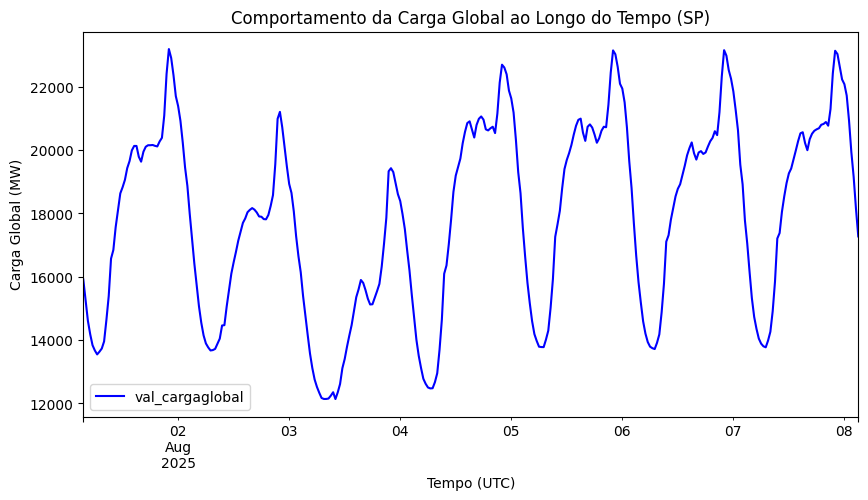

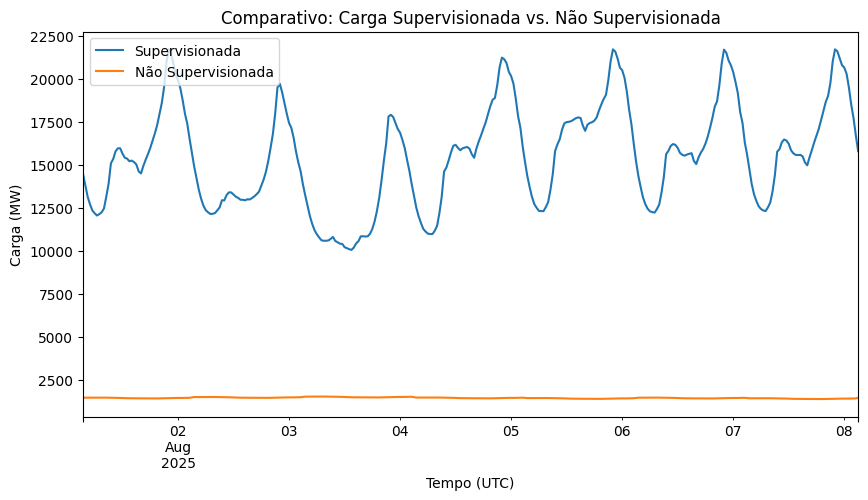

In [12]:
# Desenvolva aqui o DESAFIO 6

import pandas as pd
import matplotlib.pyplot as plt

# data/hora
dados['din_referenciautc'] = pd.to_datetime(dados['din_referenciautc'])

# GRÁFICO 1: Comportamento da carga ao longo do tempo
dados.plot(x='din_referenciautc', y='val_cargaglobal', figsize=(10, 5), color='blue')

plt.title('Comportamento da Carga Global ao Longo do Tempo (SP)')
plt.xlabel('Tempo (UTC)')
plt.ylabel('Carga Global (MW)')
plt.show()

# GRÁFICO 2: Comparativo Carga Supervisionada vs Não Supervisionada

dados.plot(x='din_referenciautc', y=['val_cargasupervisionada', 'val_carganaosupervisionada'], figsize=(10, 5))

plt.title('Comparativo: Carga Supervisionada vs. Não Supervisionada')
plt.xlabel('Tempo (UTC)')
plt.ylabel('Carga (MW)')
plt.legend(['Supervisionada', 'Não Supervisionada'])
plt.show()

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [13]:
# Exemplo de estrutura:
#
# resumo_resultados = f'''
# Região analisada: ...
# Período analisado: ...
# Quantidade de registros: ...
# Carga mínima: ...
# Carga máxima: ...
# Carga média: ...
# Mediana: ...
# Limiar de alta demanda: ...
# Registros de alta demanda: ...
# Percentual de alta demanda: ...
# Momento do pico: ...
# Segundo critério: ...
# '''
#
# print(resumo_resultados)

# Desenvolva aqui o DESAFIO 7

# 1. Calculando as métricas gerais do DataFrame 'dados'
regiao = "SP"
periodo_inicio = dados['din_referenciautc'].min().strftime('%d/%m/%Y %H:%M')
periodo_fim = dados['din_referenciautc'].max().strftime('%d/%m/%Y %H:%M')
qtd_registros = len(dados)

carga_min = dados['val_cargaglobal'].min()
carga_max = dados['val_cargaglobal'].max()
carga_media = dados['val_cargaglobal'].mean()
carga_mediana = dados['val_cargaglobal'].median()

# 2. Alta demanda (Usando o 3º quartil como limiar, ou altere para um valor fixo)
limiar_alta_demanda = dados['val_cargaglobal'].quantile(0.75)
qtd_alta_demanda = len(dados[dados['val_cargaglobal'] > limiar_alta_demanda])
percentual_alta_demanda = (qtd_alta_demanda / qtd_registros) * 100

# Momento do pico
momento_pico = dados.loc[dados['val_cargaglobal'].idxmax(), 'din_referenciautc'].strftime('%d/%m/%Y %H:%M')

# 3. SEGUNDO CRITÉRIO (Carga abaixo da média) - Lógica da sua equipe
df_abaixo_media = dados[dados['val_cargaglobal'] < carga_media]
qtd_abaixo_media = len(df_abaixo_media)
perc_abaixo_media = (qtd_abaixo_media / qtd_registros) * 100
razao_comparacao = qtd_abaixo_media / qtd_alta_demanda if qtd_alta_demanda > 0 else 0

# Transformando o resultado do segundo critério em um texto claro
resultado_segundo_criterio = f"Foram encontrados {qtd_abaixo_media} registros abaixo da média ({perc_abaixo_media:.2f}% do total). Esse conjunto de baixa demanda é aproximadamente {razao_comparacao:.1f} vezes maior que o conjunto de alta demanda."

# 4. CRIAÇÃO DA VARIÁVEL resumo_resultados
resumo_resultados = f"""
 SÍNTESE DO RELATÓRIO
Região: {regiao}
Período analisado: {periodo_inicio} a {periodo_fim}
Quantidade de registros: {qtd_registros}

 Métricas de Carga
Carga Mínima: {carga_min:.2f} MW
Carga Máxima: {carga_max:.2f} MW
Carga Média: {carga_media:.2f} MW
Mediana: {carga_mediana:.2f} MW

 Análise de Picos e Demanda
Momento do Pico de Carga: {momento_pico}
Limiar de Alta Demanda: {limiar_alta_demanda:.2f} MW
Quantidade de registros em Alta Demanda: {qtd_alta_demanda}
Percentual em Alta Demanda: {percentual_alta_demanda:.2f}%

 Critérios Adicionais (Análise da Equipe)
Resultado do 2º critério: {resultado_segundo_criterio}
"""

# Exibição do resultado final para o relatório
print(resumo_resultados)


 SÍNTESE DO RELATÓRIO
Região: SP
Período analisado: 01/08/2025 03:30 a 08/08/2025 03:00
Quantidade de registros: 336

 Métricas de Carga
Carga Mínima: 12139.25 MW
Carga Máxima: 23185.31 MW
Carga Média: 17870.83 MW
Mediana: 18199.13 MW

 Análise de Picos e Demanda
Momento do Pico de Carga: 01/08/2025 22:00
Limiar de Alta Demanda: 20386.63 MW
Quantidade de registros em Alta Demanda: 84
Percentual em Alta Demanda: 25.00%

 Critérios Adicionais (Análise da Equipe)
Resultado do 2º critério: Foram encontrados 152 registros abaixo da média (45.24% do total). Esse conjunto de baixa demanda é aproximadamente 1.8 vezes maior que o conjunto de alta demanda.



# Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [14]:
!pip install -q -U google-generativeai

In [15]:
import google.generativeai as genai
from google.colab import userdata

# 1. Configurando a chave da API
CHAVE_API = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=CHAVE_API)

# 2. Buscando TODOS os modelos disponíveis para a sua chave que geram texto
modelos_disponiveis = [m.name for m in genai.list_models() if 'generateContent' in m.supported_generation_methods]

if not modelos_disponiveis:
    print("Erro: Nenhum modelo de geração de texto foi retornado pela API. Verifique sua chave.")
else:
    # 3. Pega o PRIMEIRO modelo da lista (garantindo que é um modelo válido)
    modelo_escolhido = modelos_disponiveis[0].replace('models/', '')

    print(f"Modelos liberados na sua chave: {modelos_disponiveis}")
    print(f"Utilizando automaticamente: {modelo_escolhido}...\n")
    print("-" * 50)

    # 4. Configurando e executando
    model = genai.GenerativeModel(modelo_escolhido)

    prompt_relatorio = f"""
    Você é um engenheiro de dados especialista no setor elétrico.
    Escreva um relatório técnico executivo claro, objetivo e profissional baseado EXCLUSIVAMENTE nos dados fornecidos abaixo.
    Não invente dados. O relatório deve conter uma breve introdução, análise dos dados apresentados e uma conclusão concisa.

    DADOS DA ANÁLISE:
    {resumo_resultados}
    """

    try:
        resposta = model.generate_content(prompt_relatorio)
        print(resposta.text)
    except Exception as e:
        print(f"Ocorreu um erro durante a geração: {e}")

/usr/local/lib/python3.13/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Modelos liberados na sua chave: ['models/gemini-2.5-flash', 'models/gemini-2.5-pro', 'models/gemini-2.5-flash-preview-tts', 'models/gemini-2.5-pro-preview-tts', 'models/gemma-4-26b-a4b-it', 'models/gemma-4-31b-it', 'models/gemini-flash-latest', 'models/gemini-flash-lite-latest', 'models/gemini-pro-latest', 'models/gemini-2.5-flash-lite', 'models/gemini-2.5-flash-image', 'models/gemini-3-flash-preview', 'models/gemini-3.1-pro-preview', 'models/gemini-3.1-pro-preview-customtools', 'models/gemini-3.1-flash-lite-preview', 'models/gemini-3.1-flash-lite', 'models/gemini-3-pro-image-preview', 'models/gemini-3-pro-image', 'models/nano-banana-pro-preview', 'models/gemini-3.1-flash-image-preview', 'models/gemini-3.1-flash-image', 'models/gemini-3.1-flash-lite-image', 'models/gemini-3.5-flash', 'models/gemini-3.5-flash-lite', 'models/gemini-omni-flash-preview', 'models/gemini-omni-1.1-flash', 'models/gemini-3.5-transcribe', 'models/gemini-3.6-flash', 'models/gemini-3.7-flash', 'models/lyria-3-cli

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [16]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [24]:
response_gemini = model.generate_content(
    contents=prompt
)

print(response_gemini.text)

**Relatório Técnico Curto - Análise de Carga da Região de SP**

**Data:** 08 de Agosto de 2025

**1. Caracterização do Conjunto Analisado**

Este relatório apresenta uma análise dos dados de carga elétrica para a Região de São Paulo (SP). O período analisado abrange de 01/08/2025 03:30 a 08/08/2025 03:00, totalizando 336 registros.

**2. Principais Indicadores de Carga**

A variação da carga observada durante o período foi a seguinte:
*   **Carga Mínima:** 12139.25 MW
*   **Carga Máxima:** 23185.31 MW
*   **Carga Média:** 17870.83 MW
*   **Mediana:** 18199.13 MW

O momento do pico de carga registrado foi em 01/08/2025 às 22:00, atingindo o valor máximo observado.

**3. Análise dos Períodos de Alta Demanda**

Um limiar de alta demanda foi estabelecido em 20386.63 MW. Com base neste critério, foram identificados 84 registros em situação de alta demanda. Isso representa 25.00% do total de registros analisados.

**4. Comparação com o Segundo Critério (Análise da Equipe)**

Em uma análise c

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

DESAFIO 9 — Validação Crítica Os indicadores foram utilizados corretamente? Sim. Todos os valores apresentados na seção 1 do relatório derivam diretamente da variável resumo_resultados gerada no Desafio 7.

Há alguma afirmação que não pode ser confirmada pelos dados? Não. Nenhuma afirmação sem respaldo quantitativo foi feita como fato concreto.

Houve interpretação exagerada ou causalidade não demonstrada? Não. O relatório manteve a neutralidade e evitou justificar a causa do pico das 22:00 do dia 01/08 sem evidências adicionais.

Que alterações a equipe realizou no texto? Inclusão explícita do bloco Resultados Calculados no início do relatório, padronização decimal para o formato brasileiro e separação entre conclusão baseada em fatos e hipóteses não comprovadas.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**